# Language Distribution Analysis

Below is an analysis of the language distribution in the processed dataset:

## Bar Graph
Obtained with _value_counts_ function to show visually the distribution

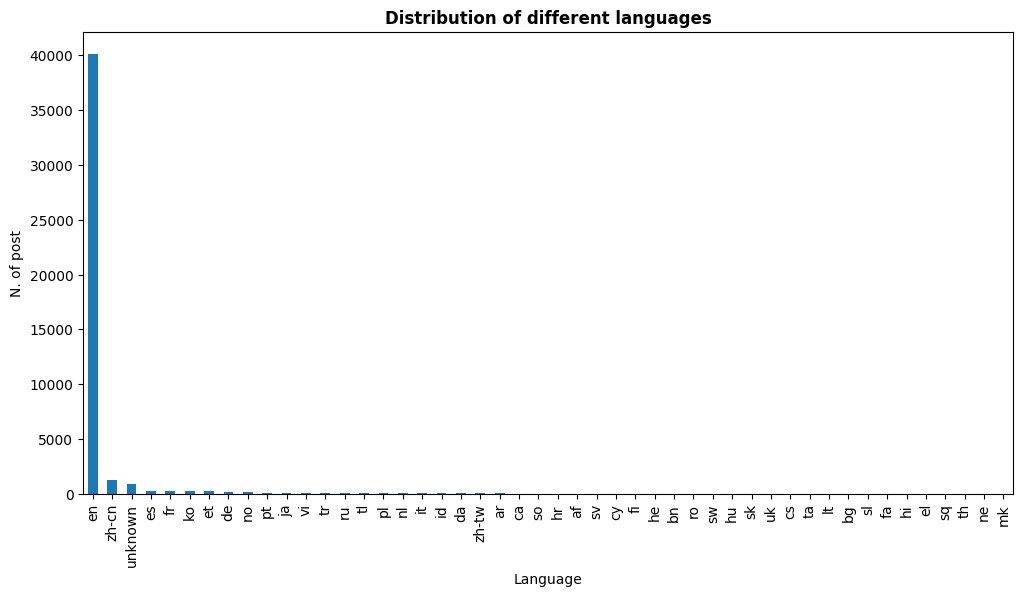

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

data_new = pd.read_parquet('../data/processed/processed_lang.parquet')

data_new['language'].value_counts().plot(kind='bar', figsize=(12,6))
plt.title('Distribution of different languages', fontweight='bold')
plt.ylabel('N. of post')
plt.xlabel('Language')
plt.show()

## First 10 languages table
Shows counts and percentages of the first 10 languages found in the dataset

In [11]:
lang_stats = pd.DataFrame({
    'Counts': data_new['language'].value_counts(),
    'Percentage': (data_new['language'].value_counts() / len(data_new) * 100).round(2)
})

lang_stats = lang_stats.reset_index()
lang_stats.columns = ['Language', 'Counts', 'Percentage']

lang_stats.head(10)

,Language,Counts,Percentage
0,en,40150,90.48
1,zh-cn,1256,2.83
2,unknown,858,1.93
3,es,264,0.59
4,fr,214,0.48
5,ko,206,0.46
6,et,203,0.46
7,de,140,0.32
8,no,119,0.27
9,pt,111,0.25


## Cleaning dataset
Since the english language is the most common in this dataset, the analysis will be done with only the english model from SpaCy.
In the following cell I'll delete all the rows not in english, making the dataset more clear and easy to process.

In [16]:
eng_data = data_new[data_new['language'] == 'en']

eng_data.to_parquet('../data/processed/english_data.parquet')